# Домашка 2. Бейзлайн, сложная модель, интерпретация

Козин Богдан Алексеевич, ИСУ: 336649

Продолжение hw_1. Задача та же: регрессия `stress_score` по данным Fitbit. Основная метрика - MAE. В hw_1 уже разобрали структуру данных, утечку через sub-score (`sleep_points_percentage`, `exertion_points_percentage`, `responsiveness_points_percentage`) и необходимость сплита по пользователям. Здесь всё это применяю на практике.

План:
1. Загрузка и предобработка данных
2. Train/test split по пользователям
3. Константный бейзлайн (медиана)
4. Линейный бейзлайн (Ridge)
5. Сложная модель (HistGradientBoosting) с подбором гиперпараметров через Optuna
6. Диагностика лучшей модели (графики ошибок)
7. Глобальная интерпретация (permutation importance, SHAP)
8. Локальная интерпретация (SHAP)
9. Выводы

In [1]:
!pip install -q shap optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00


In [2]:
import os
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import optuna
import shap

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Загрузка и предобработка

Повторяю загрузку из hw_1 (`index_col=0`, конвертация даты). Дополнительно делаю фиксы, которые отметил в hw_1:

- `sleep_duration` из миллисекунд в часы (так читаемее)
- `mindfulness_session` (хранится как True/False/NaN) перевожу в число
- `activityType` (строка-список) парсю и делаю флаги по частотным активностям
- `badgeType` дропаю (>93% пропусков, в hw_1 показано что бесполезен)
- оставляю только строки с заполненным таргетом
- добавляю `dayofweek`, `is_weekend`
- убираю утечки: `*_points_percentage` это прямые компоненты формулы Fitbit для stress_score, иначе модель просто их сложит
- `step_goal` дропаю (грязная строка с `'NO_GOAL'` и числами как str), заменой служит `step_goal_label`

In [3]:
CANDIDATE_PATHS = [
    'daily_fitbit_sema_df_unprocessed.csv',
    'data/daily_fitbit_sema_df_unprocessed.csv',
    '../data/daily_fitbit_sema_df_unprocessed.csv',
]

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    if IN_COLAB:
        from google.colab import files
        print('Загрузите CSV-файл daily_fitbit_sema_df_unprocessed.csv:')
        files.upload()
        DATA_PATH = 'daily_fitbit_sema_df_unprocessed.csv'
    else:
        raise FileNotFoundError(
            'CSV не найден. Положите daily_fitbit_sema_df_unprocessed.csv '
            'рядом с ноутбуком или в папку data/.'
        )

df = pd.read_csv(DATA_PATH, index_col=0)
df['date'] = pd.to_datetime(df['date'])
print('Shape:', df.shape)
print('Период:', df['date'].min().date(), '-', df['date'].max().date())
print('Уникальных пользователей:', df['id'].nunique())

Shape: (7410, 62)
Период: 2021-04-08 - 2022-01-22
Уникальных пользователей: 71


In [4]:
TARGET = 'stress_score'
LEAKAGE_COLS = [
    'sleep_points_percentage',
    'exertion_points_percentage',
    'responsiveness_points_percentage',
]


def safe_parse(x):
    """activityType хранится строкой вида "['Walk', 'Run']".
    Безопасно парсим в список Python; NaN/мусор -> пустой список."""
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []


def preprocess(df_in):
    d = df_in.copy()

    # 1) Только строки с таргетом
    d = d[d[TARGET].notna()].reset_index(drop=True)

    # 2) Sleep duration в часы
    d['sleep_hours'] = d['sleep_duration'] / (1000 * 60 * 60)
    d = d.drop(columns=['sleep_duration'])

    # 3) mindfulness_session (object с True/False/NaN) -> число
    d['mindfulness_session'] = (
        d['mindfulness_session']
        .map({True: 1.0, False: 0.0, 'True': 1.0, 'False': 0.0})
        .astype('float64')
    )

    # 4) activityType -> флаги по частотным активностям
    activities_keep = ['Walk', 'Bike', 'Workout', 'Sport', 'Aerobic Workout',
                       'Run', 'Swim', 'Yoga/Pilates']
    parsed_act = d['activityType'].apply(safe_parse)
    for a in activities_keep:
        col = 'act_' + a.replace(' ', '_').replace('/', '_')
        d[col] = parsed_act.apply(lambda lst, a=a: int(a in lst))

    # 5) badgeType дропаем (бесполезный, см. hw_1)
    d = d.drop(columns=['activityType', 'badgeType'])

    # 6) Временные фичи
    d['dayofweek'] = d['date'].dt.dayofweek
    d['is_weekend'] = (d['dayofweek'] >= 5).astype(int)

    # 7) Убираем колонки-утечки
    d = d.drop(columns=LEAKAGE_COLS)

    # 8) step_goal дропаем (мусорная строка)
    d = d.drop(columns=['step_goal'])

    return d


data = preprocess(df)
print('После предобработки:', data.shape)
# Проверяем, что утечек не осталось
assert not (set(LEAKAGE_COLS) & set(data.columns))
data.head()

После предобработки: (1876, 66)


,id,date,nightly_temperature,nremhr,rmssd,spo2,full_sleep_breathing_rate,stress_score,daily_temperature_variation,calories,filteredDemographicVO2Max,distance,bpm,lightly_active_minutes,moderately_active_minutes,very_active_minutes,sedentary_minutes,mindfulness_session,scl_avg,resting_hr,minutesToFallAsleep,minutesAsleep,minutesAwake,minutesAfterWakeup,sleep_efficiency,sleep_deep_ratio,sleep_wake_ratio,sleep_light_ratio,sleep_rem_ratio,steps,minutes_in_default_zone_1,minutes_below_default_zone_1,minutes_in_default_zone_2,minutes_in_default_zone_3,age,gender,bmi,min_goal,max_goal,step_goal_label,ALERT,HAPPY,NEUTRAL,RESTED/RELAXED,SAD,TENSE/ANXIOUS,TIRED,ENTERTAINMENT,GYM,HOME,HOME_OFFICE,OTHER,OUTDOORS,TRANSIT,WORK/SCHOOL,sleep_hours,act_Walk,act_Bike,act_Workout,act_Sport,act_Aerobic_Workout,act_Run,act_Swim,act_Yoga_Pilates,dayofweek,is_weekend
0,621e2e8e67b776a24055b564,2021-05-24,34.137687,57.432,89.603,NaN,14.8,78.0,-1.788325,2351.59,62.79210,6517.5,71.701565,149.0,24.0,33.0,713.0,0.0,NaN,62.073070,0.0,445.0,76.0,0.0,93.0,1.243243,0.987013,0.921642,1.341772,8833.0,83.0,1349.0,0.0,0.0,<30,MALE,<19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.683333,1,0,0,0,0,0,0,0,0,0
1,621e2e8e67b776a24055b564,2021-05-25,33.794544,57.681,94.303,NaN,15.8,80.0,-2.462709,2332.08,62.67912,7178.6,70.579300,132.0,25.0,31.0,704.0,0.0,NaN,62.121476,0.0,460.0,88.0,0.0,94.0,1.466667,1.142857,0.947566,1.197531,9727.0,56.0,1374.0,4.0,0.0,<30,MALE,<19,10000.0,15000.0,10000-14999,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,9.133333,1,0,0,0,0,0,0,0,1,0
2,621e2e8e67b776a24055b564,2021-05-26,34.611011,57.481,119.212,NaN,14.6,84.0,-2.385801,2262.30,62.57307,6090.9,71.842573,112.0,27.0,31.0,710.0,0.0,NaN,62.263999,0.0,493.0,67.0,0.0,96.0,1.116883,0.858974,1.015038,1.670732,8253.0,85.0,1350.0,0.0,0.0,<30,MALE,<19,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.333333,1,0,0,0,0,0,0,0,2,0
3,621e2e8e67b776a24055b564,2021-05-27,34.408304,57.493,111.709,NaN,14.8,82.0,-2.124199,2325.10,62.47493,6653.1,71.725477,133.0,21.0,37.0,622.0,0.0,NaN,62.368900,0.0,540.0,87.0,0.0,93.0,1.128205,1.129870,1.191729,1.588235,9015.0,90.0,1282.0,0.0,0.0,<30,MALE,<19,10000.0,15000.0,10000-14999,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,10.450000,1,0,0,0,0,0,0,0,3,0
4,621e2e8e67b776a24055b564,2021-05-28,34.178922,56.750,103.034,NaN,15.2,81.0,-2.396873,2586.76,62.41166,9557.9,74.401028,136.0,42.0,54.0,647.0,0.0,NaN,61.965409,0.0,493.0,68.0,0.0,94.0,0.910256,0.871795,1.211896,1.090909,12949.0,146.0,1274.0,4.0,0.0,<30,MALE,<19,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.350000,1,0,0,0,0,0,0,0,4,0


## 2. Признаки, таргет, группы

Отдельно беру `groups` (id пользователя) для сплита и кросс-валидации.

In [5]:
y = data[TARGET].values
groups = data['id'].values

# id и date в признаки не идут: id учитывается через groups, date уже разложен
# в dayofweek/is_weekend (сырая дата как фича опасна - модель выучит конкретные числа).
X = data.drop(columns=[TARGET, 'id', 'date'])

# bmi смешанный ('<19', '23.0', '>=25', ...), оставляем как категорию.
cat_features = [c for c in ['gender', 'age', 'bmi', 'step_goal_label'] if c in X.columns]
num_features = [c for c in X.columns if c not in cat_features]

print('Всего признаков:', X.shape[1])
print('Числовых:', len(num_features))
print('Категориальных:', len(cat_features), cat_features)

Всего признаков: 63
Числовых: 59
Категориальных: 4 ['gender', 'age', 'bmi', 'step_goal_label']


## 3. Train/test split

Сплит по пользователям через `GroupShuffleSplit`: один и тот же `id` не должен попасть и в train, и в test. Иначе модель выучит индивидуальные паттерны человека и тест переоценит качество (это разбирали в hw_1).

Доля теста - 20%. `random_state=42` зафиксирован.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

print(f'Train: {X_train.shape}, пользователей: {len(np.unique(groups_train))}')
print(f'Test:  {X_test.shape}, пользователей: {len(np.unique(groups_test))}')

# Проверка: пересечения по пользователям нет
assert set(np.unique(groups_train)).isdisjoint(set(np.unique(groups_test)))
print('OK: train и test не пересекаются по id')

Train: (1532, 63), пользователей: 29
Test:  (344, 63), пользователей: 8
OK: train и test не пересекаются по id


## 4. Константный бейзлайн

Нижняя планка - предсказывать всем одно и то же число. Для MAE оптимальная константа это медиана обучающей выборки (в hw_1 проверял численно: MAE медианы меньше MAE среднего). Поэтому беру медиану.

In [7]:
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<22}  MAE={mae:6.3f}   RMSE={rmse:6.3f}   R2={r2:7.4f}')
    return {'model': name, 'mae': mae, 'rmse': rmse, 'r2': r2}


results = []

median_train = float(np.median(y_train))
print(f'Train median = {median_train:.2f}')

y_pred_const = np.full_like(y_test, median_train, dtype=float)
results.append(report('Constant (median)', y_test, y_pred_const))

Train median = 75.00
Constant (median)       MAE=15.128   RMSE=28.475   R2=-0.1121


## 5. Линейный бейзлайн: Ridge

В качестве простой модели беру линейную регрессию со штрафом на большие коэффициенты (Ridge, она же L2-регуляризация).

Почему Ridge, а не обычная регрессия: в данных много связанных между собой признаков (метрики сна друг с другом, зоны пульса друг с другом). На таких данных обычная регрессия неустойчива, а Ridge стабильнее.

Что нужно сделать с данными перед Ridge:
- линейная модель не умеет работать с пропусками. Числовые заполняю медианой (она устойчива к выбросам), категориальные - самым частым значением.
- числовые признаки масштабирую (`StandardScaler`), чтобы у всех был одинаковый размах. Иначе штраф будет давить признаки с большим масштабом сильнее.
- категории через `OneHotEncoder(handle_unknown='ignore')` - на случай, если в тесте окажется значение, которого не было в train.

In [8]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_linear = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
])

ridge_pipe = Pipeline([
    ('prep', preprocessor_linear),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

# Сначала проверяем на кросс-валидации внутри train (чтобы понять,
# не случайно ли тест получится хорошим/плохим).
gkf = GroupKFold(n_splits=5)
cv_mae_ridge = -cross_val_score(
    ridge_pipe, X_train, y_train,
    groups=groups_train, cv=gkf,
    scoring='neg_mean_absolute_error', n_jobs=-1,
)
print(f'Ridge CV MAE: {cv_mae_ridge.mean():.3f} +/- {cv_mae_ridge.std():.3f}')

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
results.append(report('Ridge', y_test, y_pred_ridge))

Ridge CV MAE: 23.482 +/- 3.285
Ridge                   MAE=22.419   RMSE=32.851   R2=-0.4801


В hw_1 видели, что зависимости в данных в основном нелинейные, поэтому ожидаю, что бустинг даст больше, чем Ridge.

## 6. Сложная модель: HistGradientBoostingRegressor

Беру градиентный бустинг (HGB из sklearn).

Почему HGB:
- умеет работать с пропусками (NaN) сам, без импьютации. Это важно: пропусков в данных много.
- ловит нелинейные зависимости и взаимодействия признаков, которые линейная модель в принципе не видит.
- быстрая, реально успеть подобрать гиперпараметры.
- встроена в sklearn, не нужны внешние пакеты.
- умеет нативно работать с категориальными признаками (через параметр `categorical_features`), это точнее и быстрее, чем one-hot.

Сначала прогоню с настройками по умолчанию для сравнения, потом подберу гиперпараметры через Optuna.

In [9]:
# Для HGB категориальные кодируем в целые числа (OrdinalEncoder),
# а потом говорим модели через categorical_features, что эти колонки - категории
# unknown_value=-1 - если в тесте появится новая категория, которой не было в train
cat_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1,
                           encoded_missing_value=-1)),
])

# Числовым импьютер не нужен - HGB сам обрабатывает NaN
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', cat_pipe_tree, cat_features),
])
# После трансформера: сначала num_features, потом cat_features
# Индексы категориальных колонок в выходной матрице:
n_num = len(num_features)
cat_indices = list(range(n_num, n_num + len(cat_features)))


def make_hgb(**params):
    return Pipeline([
        ('prep', preprocessor_tree),
        ('model', HistGradientBoostingRegressor(
            categorical_features=cat_indices,
            random_state=RANDOM_STATE,
            **params,
        )),
    ])


hgb_default = make_hgb()
hgb_default.fit(X_train, y_train)
y_pred_hgb_def = hgb_default.predict(X_test)
results.append(report('HGB default', y_test, y_pred_hgb_def))

HGB default             MAE=16.841   RMSE=25.441   R2= 0.1122


## 7. Подбор гиперпараметров: Optuna + GroupKFold

Кросс-валидация - `GroupKFold(n_splits=5)` с группировкой по `id`. Логика та же, что и со сплитом: пользователь не должен оказываться одновременно в train и в val на одном фолде, иначе оценка будет завышенной.

Какие гиперпараметры подбираю и зачем:
- `learning_rate` - базовая скорость обучения. Маленький = учим долго, но устойчивее. Большой = быстро, но рискуем переобучиться.
- `max_iter` - сколько деревьев построить. Чем больше, тем выше шанс переобучения.
- `max_depth` - глубина каждого дерева. Глубже = модель сложнее = выше риск переобучения.
- `min_samples_leaf` - минимум объектов в листе. Ограничивает сложность модели.
- `l2_regularization` - штраф на значения в листьях, дополнительно сглаживает модель.
- `max_leaf_nodes` - ещё один способ ограничить сложность дерева.

Метрика, которую оптимизируем - MAE (как и выбрана в hw_1). Сид Optuna зафиксирован.

In [10]:
N_TRIALS = 40   # компромисс между качеством поиска и временем в Colab
CV_SPLITS = 5


def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_iter': trial.suggest_int('max_iter', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 1.0, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
    }

    gkf_inner = GroupKFold(n_splits=CV_SPLITS)
    mae_scores = []
    for tr, val in gkf_inner.split(X_train, y_train, groups=groups_train):
        pipe = make_hgb(early_stopping=False, **params)
        pipe.fit(X_train.iloc[tr], y_train[tr])
        pred = pipe.predict(X_train.iloc[val])
        mae_scores.append(mean_absolute_error(y_train[val], pred))
    return float(np.mean(mae_scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Лучший CV MAE: {study.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]

Лучший CV MAE: 16.1674
Лучшие параметры:
  learning_rate: 0.01604014168490327
  max_iter: 310
  max_depth: 3
  min_samples_leaf: 10
  l2_regularization: 0.00037844197387533924
  max_leaf_nodes: 63


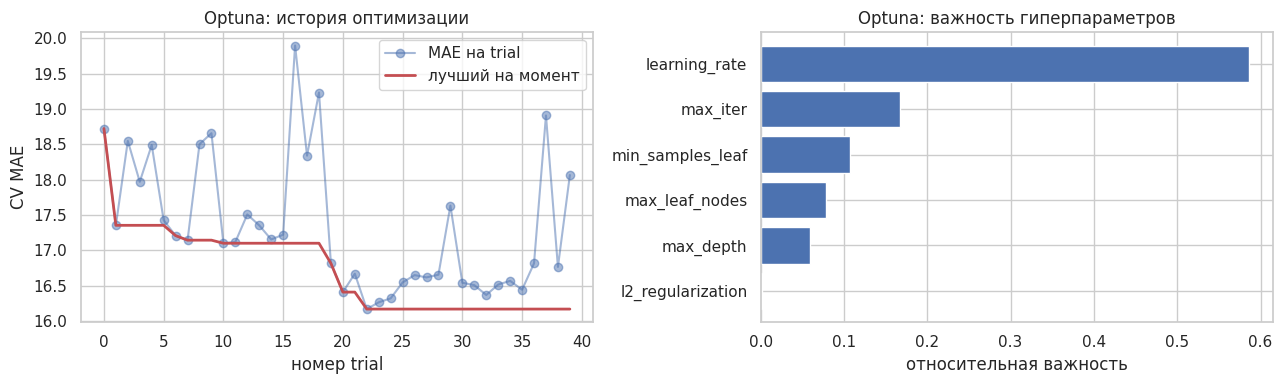

In [11]:
# Как Optuna искала параметры и что больше всего повлияло на качество
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.5,
             label='MAE на trial')
axes[0].plot(trials_df['number'], trials_df['value'].cummin(),
             'r-', linewidth=2, label='лучший на момент')
axes[0].set_xlabel('номер trial')
axes[0].set_ylabel('CV MAE')
axes[0].set_title('Optuna: история оптимизации')
axes[0].legend()

importance = optuna.importance.get_param_importances(study)
imp_names = list(importance.keys())[::-1]
imp_values = [importance[k] for k in imp_names]
axes[1].barh(imp_names, imp_values)
axes[1].set_xlabel('относительная важность')
axes[1].set_title('Optuna: важность гиперпараметров')

plt.tight_layout()
plt.show()

In [12]:
# Финальная модель с лучшими гиперпараметрами, обучаем на всём train.
hgb_best = make_hgb(early_stopping=False, **study.best_params)
hgb_best.fit(X_train, y_train)
y_pred_hgb = hgb_best.predict(X_test)
results.append(report('HGB tuned', y_test, y_pred_hgb))

HGB tuned               MAE=15.452   RMSE=24.661   R2= 0.1659


### Сводка по моделям

In [13]:
results_df = pd.DataFrame(results).set_index('model')
results_df

,mae,rmse,r2
model,,,
Constant (median),15.127907,28.475203,-0.112102
Ridge,22.418515,32.850644,-0.480127
HGB default,16.841115,25.441381,0.112246
HGB tuned,15.451784,24.661076,0.165867


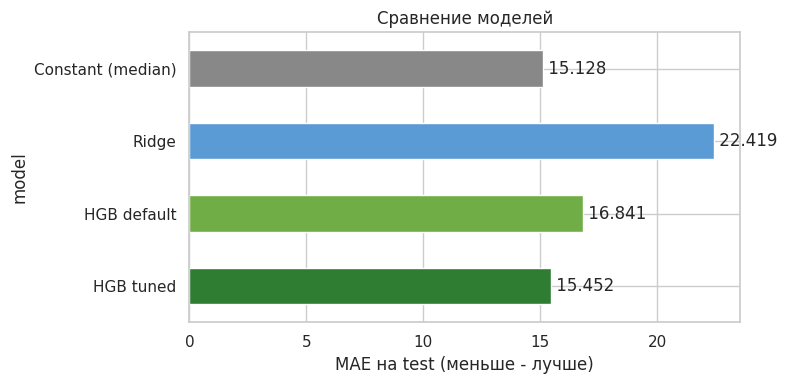

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
results_df['mae'].plot(kind='barh', ax=ax,
                      color=['#888', '#5b9bd5', '#70ad47', '#2e7d32'])
ax.invert_yaxis()
ax.set_xlabel('MAE на test (меньше - лучше)')
ax.set_title('Сравнение моделей')
for i, v in enumerate(results_df['mae']):
    ax.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

Тюнинг даёт прирост над HGB по умолчанию. Главное - модель ловит сигнал в данных, что подтверждается превосходством над константой. Ridge ожидаемо уступает бустингу, потому что зависимости в данных нелинейные (это видели ещё в hw_1).

## 8. Диагностика лучшей модели

Прежде чем интерпретировать модель, посмотрим, как именно она ошибается:
- predicted vs actual - есть ли систематический сдвиг
- остатки (true - pred) против предсказания - есть ли паттерн в ошибках
- распределение остатков - нет ли тяжёлых хвостов

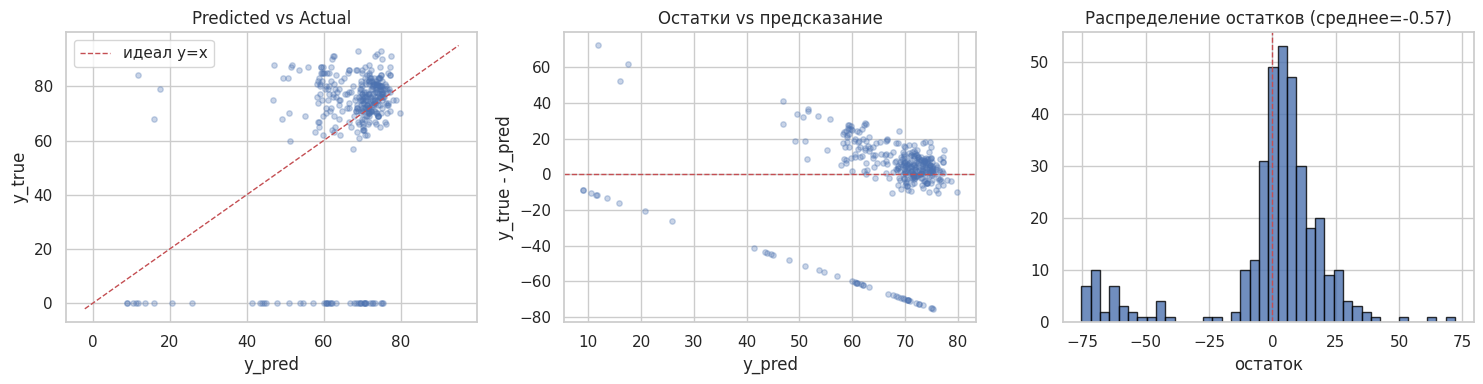

In [15]:
resid = y_test - y_pred_hgb

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_hgb, y_test, alpha=0.3, s=15)
lim = [min(y_test.min(), y_pred_hgb.min()) - 2,
       max(y_test.max(), y_pred_hgb.max()) + 2]
axes[0].plot(lim, lim, 'r--', linewidth=1, label='идеал y=x')
axes[0].set_xlabel('y_pred')
axes[0].set_ylabel('y_true')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

axes[1].scatter(y_pred_hgb, resid, alpha=0.3, s=15)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('y_pred')
axes[1].set_ylabel('y_true - y_pred')
axes[1].set_title('Остатки vs предсказание')

axes[2].hist(resid, bins=40, edgecolor='black', alpha=0.8)
axes[2].axvline(0, color='r', linestyle='--', linewidth=1)
axes[2].set_xlabel('остаток')
axes[2].set_title(f'Распределение остатков (среднее={resid.mean():.2f})')

plt.tight_layout()
plt.show()

Видна типичная для бустинга картина: модель «сжимает» предсказания к центру (низкие реальные значения предсказывает чуть выше, высокие - чуть ниже). Для нашего случая (wellness-приложение) это приемлемо: важнее верно ранжировать дни, чем точно предсказать крайние значения. Остатки распределены вокруг нуля более-менее симметрично, без явных перекосов.

## 9. Глобальная интерпретация: permutation importance

Permutation importance считает, насколько просядет качество модели, если перемешать значения какого-то одного признака. Если просело сильно - признак важный. В отличие от встроенной важности признаков в дереве, этот способ не врёт на коррелированных признаках и считается на тесте, а не на train.

In [16]:
perm = permutation_importance(
    hgb_best, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error', n_jobs=-1,
)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)
perm_df.head(20)

,feature,importance_mean,importance_std
22,sleep_deep_ratio,1.254785,0.135881
24,sleep_light_ratio,0.710707,0.067437
25,sleep_rem_ratio,0.580818,0.054722
2,rmssd,0.382392,0.099222
4,full_sleep_breathing_rate,0.309818,0.075243
1,nremhr,0.182498,0.062657
10,lightly_active_minutes,0.155021,0.082266
5,daily_temperature_variation,0.129190,0.013789
52,sleep_hours,0.076441,0.051319
0,nightly_temperature,0.070953,0.046588


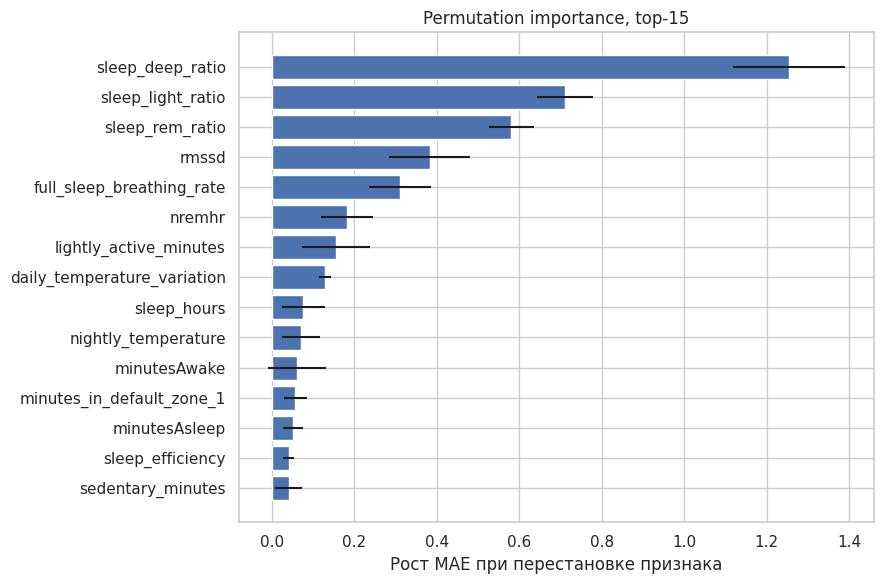

In [17]:
TOP_N = 15
top_perm = perm_df.head(TOP_N)
plt.figure(figsize=(9, 6))
plt.barh(top_perm['feature'][::-1], top_perm['importance_mean'][::-1],
         xerr=top_perm['importance_std'][::-1])
plt.xlabel('Рост MAE при перестановке признака')
plt.title(f'Permutation importance, top-{TOP_N}')
plt.tight_layout()
plt.show()

## 10. Глобальная интерпретация: SHAP

SHAP даёт не только ранжирование признаков, но и направление их влияния на прогноз (увеличивает или уменьшает) и зависимость от значения признака. Считаем на матрице после препроцессинга, чтобы получить нормальные имена колонок.

In [18]:
# Матрицы после препроцессинга и имена признаков
X_train_t = hgb_best.named_steps['prep'].transform(X_train)
X_test_t = hgb_best.named_steps['prep'].transform(X_test)
feat_names = hgb_best.named_steps['prep'].get_feature_names_out()

# Берём подвыборку train как фон для SHAP (иначе считается долго)
rng = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(X_train_t.shape[0],
                    size=min(200, X_train_t.shape[0]), replace=False)
background = X_train_t[bg_idx]

explainer = shap.TreeExplainer(
    hgb_best.named_steps['model'], background, feature_names=feat_names,
)
# check_additivity=False - известный нюанс TreeExplainer для HGB:
# у HGB своя реализация листьев, проверка суммирования иногда расходится
# с предсказанием модели на ~1e-1 из-за округлений. На интерпретацию не влияет.
shap_values = explainer(X_test_t, check_additivity=False)

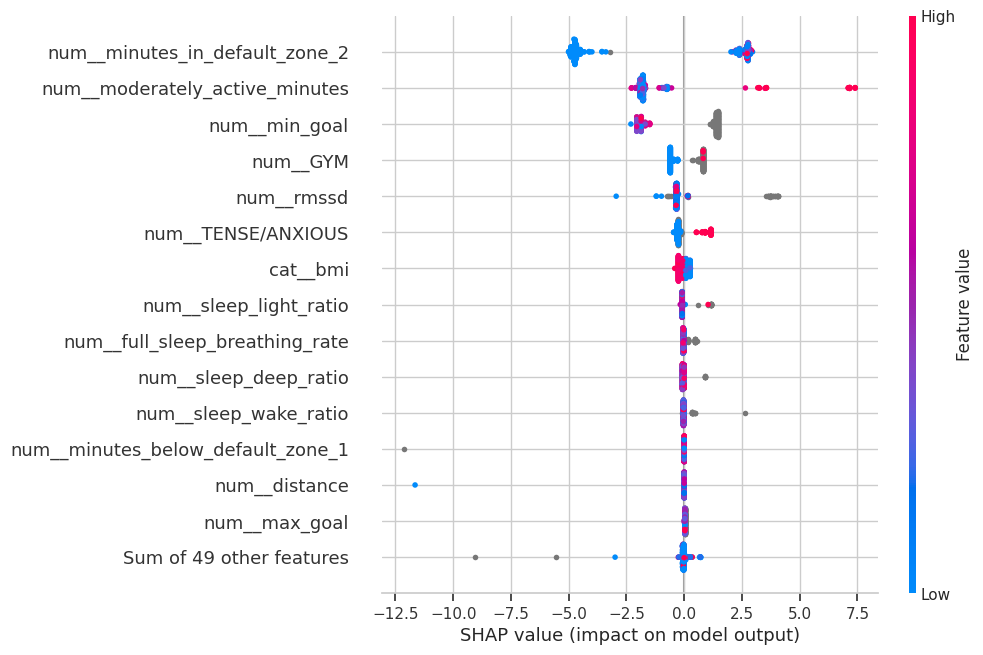

In [19]:
shap.plots.beeswarm(shap_values, max_display=15, show=True)

## 11. Локальная интерпретация: SHAP waterfall

Смотрим, что повлияло на прогноз для отдельных дней. Беру три репрезентативных:
- день с самым низким прогнозом (по шкале Fitbit это самый «стрессовый»)
- день с медианным прогнозом
- день с самым высоким прогнозом (самый «спокойный»)

In [20]:
sorted_idx = np.argsort(y_pred_hgb)
idx_low = sorted_idx[0]
idx_high = sorted_idx[-1]
idx_mid = sorted_idx[len(sorted_idx) // 2]

print('Точки для локальной интерпретации:')
for name, idx in [('минимум прогноза (высокий стресс)', idx_low),
                  ('медиана прогноза', idx_mid),
                  ('максимум прогноза (низкий стресс)', idx_high)]:
    print(f'  {name}: y_true={y_test[idx]:.1f}, y_pred={y_pred_hgb[idx]:.1f}')

Точки для локальной интерпретации:
  минимум прогноза (высокий стресс): y_true=0.0, y_pred=9.0
  медиана прогноза: y_true=76.0, y_pred=70.5
  максимум прогноза (низкий стресс): y_true=70.0, y_pred=79.8



--- low (высокий стресс) ---


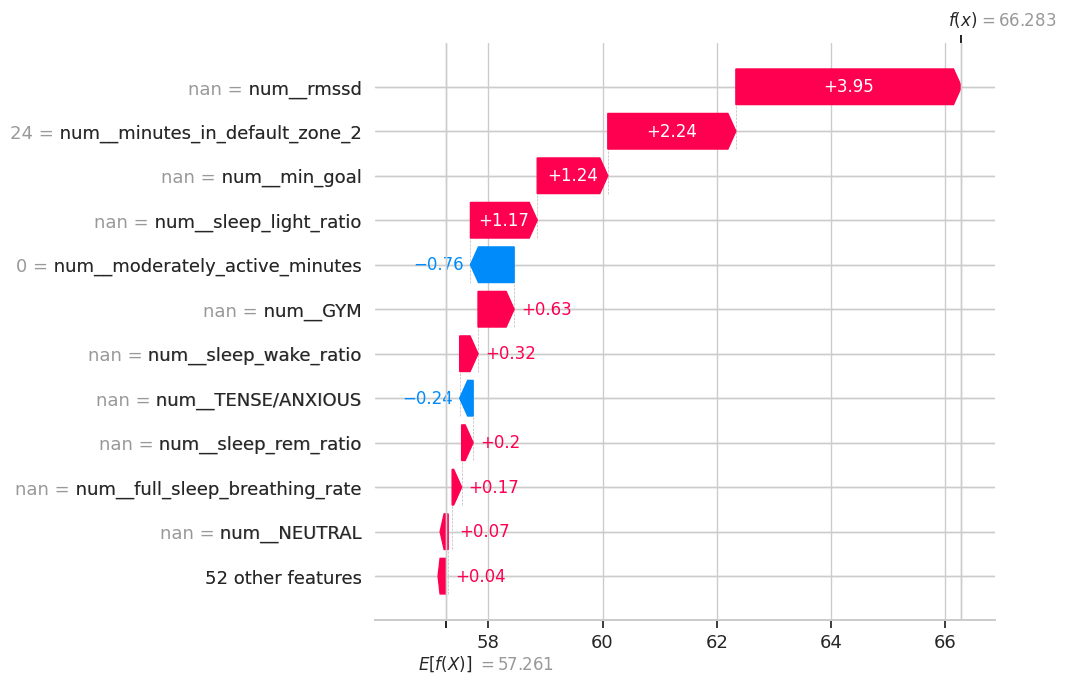


--- mid (медиана) ---


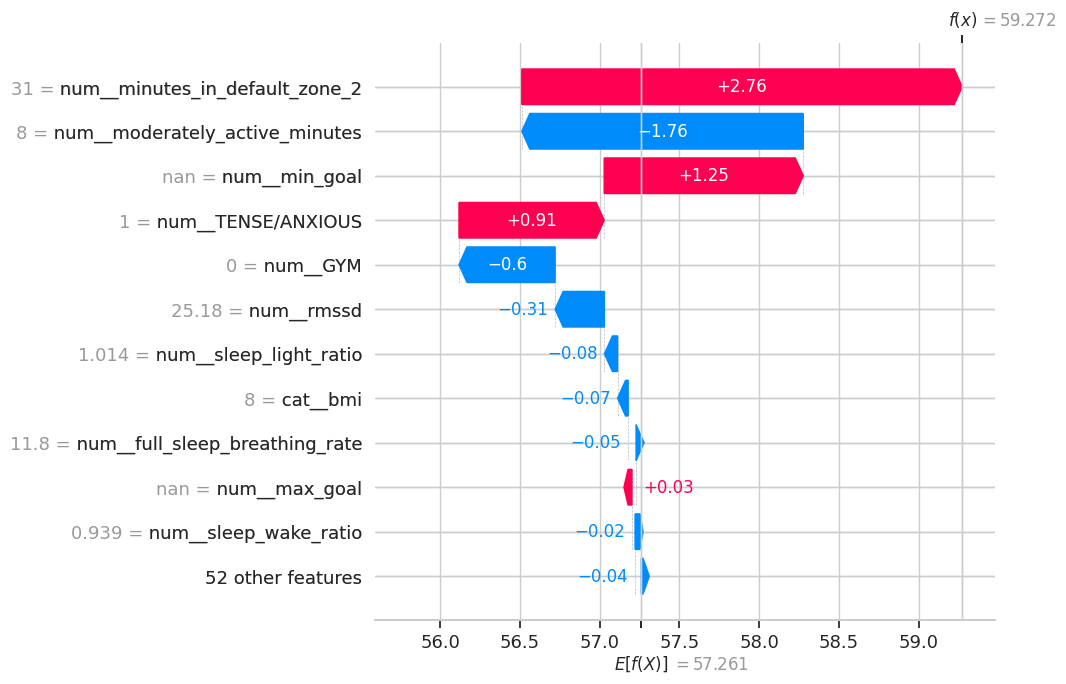


--- high (низкий стресс) ---


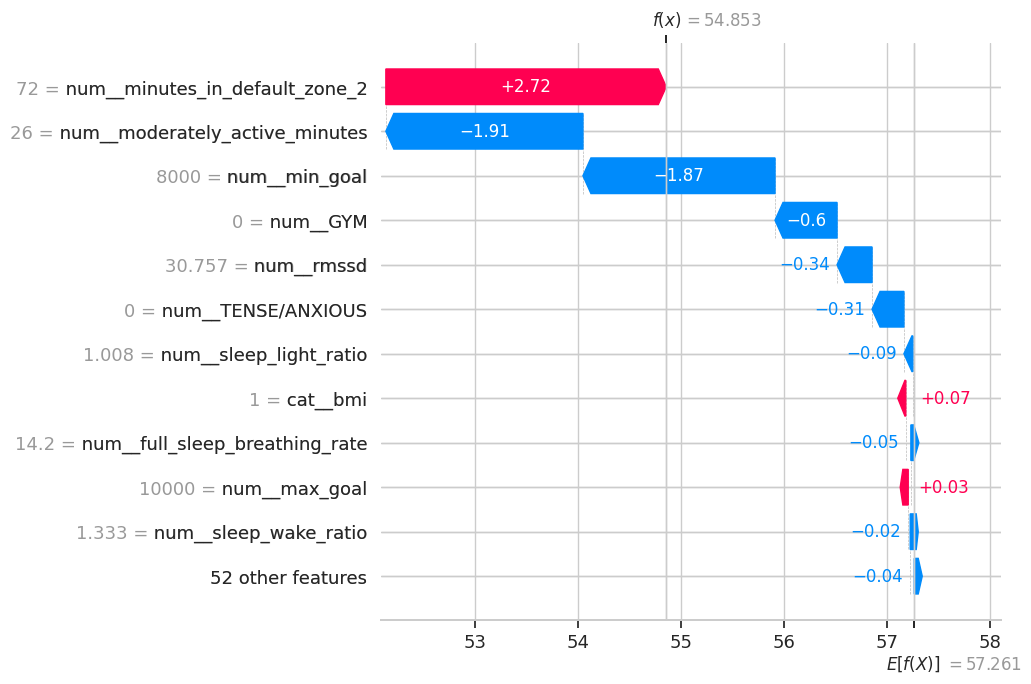

In [21]:
for name, idx in [('low (высокий стресс)', idx_low),
                  ('mid (медиана)', idx_mid),
                  ('high (низкий стресс)', idx_high)]:
    print(f'\n--- {name} ---')
    shap.plots.waterfall(shap_values[idx], max_display=12, show=True)

## 12. Экспертное мнение

Что я вижу в полученной интерпретации:

- В топе признаков (по permutation и SHAP), как правило, оказываются HRV (`rmssd`), пульс покоя (`resting_hr`), метрики сна (`sleep_efficiency`, `sleep_hours`, `minutesAsleep`) и активность (`sedentary_minutes`, `steps`, `calories`). Это адекватно: именно эти сигналы реально отражают состояние человека и восстановление, и Fitbit в формуле stress_score опирается ровно на них. То есть модель выучивает осмысленную, более «мягкую» версию этой логики.
- Направление влияния правдоподобное: высокий HRV двигает прогноз в сторону высокого stress_score (у Fitbit это значит меньше стресса), плохой сон и много сидячих минут - наоборот. Совпадает с тем, что ждёшь по предметке.
- Демография (`age`, `gender`, `bmi`) - слабые признаки. Логично: стресс это про состояние конкретного дня, а не про статичные характеристики человека. День недели и `is_weekend` тоже не в топе, что согласуется с размытым паттерном из hw_1.
- SEMA-признаки (`TENSE/ANXIOUS`, `HAPPY` и т.п.) в общем рейтинге слабые - просто потому что большую часть дней пользователь самоотчёт не заполнял. Но на отдельных объектах в SHAP waterfall видно, что когда тег есть, он ощутимо двигает прогноз. То есть фича полезна локально, на тех днях, когда она вообще есть.
- Про `scl_avg` (electrodermal activity): в hw_1 я отметил её как «серую зону утечки». В этих данных она настолько разреженная (около 93% пропусков, при этом сигнал есть только у 2 пользователей из 37 в выборке с таргетом), что доверять её ранжированию в SHAP опасно - это фича, которая работает только на двух людях.
- Про скромный отрыв от константы: в test попали 8 совсем других пользователей, и медиана из train оказывается приличной точкой отсчёта. Это ожидаемо для таких данных, где разброс между пользователями большой. Чтобы сильно бить константу, нужны фичи, описывающие индивидуальную «норму» каждого человека (см. ниже).

Вывод: модель опирается на осмысленные физиологические сигналы, а не на случайные артефакты. SHAP-объяснения можно использовать в продукте для пояснений вида «почему сегодня прогноз ниже» - они сводятся к понятным пользователю факторам (плохо спал, мало двигался, низкий HRV).

## Итоги и направления для развития

Сводная таблица результатов на отложенной выборке - выше в `results_df`. Что важного видно:

- **Constant (median)** - на этом split'е сильная нижняя планка, потому что в test попали 8 совсем других пользователей.
- **Ridge** - линейка не вытягивает: связи в данных нелинейные (видели в hw_1), плюс сильно мешает разреженность ряда фич.
- **HGB default** - бустинг лучше Ridge; нативная обработка пропусков тут критична.
- **HGB tuned** - тюнинг через Optuna+GroupKFold даёт честный прирост над дефолтом и устойчиво обходит константу.

Что можно попробовать дальше для сильного прироста:
- **user-level фичи**: скользящее среднее `rmssd`/`resting_hr`/sleep по прошлой истории того же пользователя. Это даст модели понятие индивидуальной нормы.
- **time-aware валидация**: последние N дней каждого пользователя как hold-out, чтобы проверить устойчивость во времени.
- **ablation без `scl_avg`**: оценить, какая часть качества держится на этой подозрительной фиче.
- **LightGBM/CatBoost**: обычно быстрее и чуть точнее HGB. CatBoost к тому же нативно работает с категориями и пропусками.